# Question 5

Consider the unconstrained problem  

$$
\mathrm{minimize}\quad f(\boldsymbol{x})=-\sum_{i=1}^{m}\log(1-a_{i}^{\top}\boldsymbol{x})-\sum_{i=1}^{n}\log(1-x_{i}^{2}),
$$  

with variable $x\in\mathbf{R}^{n}$ , and $\operatorname{dom}f=\{x|a_{i}^{\top}x<1,i=1,\ldots,m,|x_{i}|<1,i=1,\ldots,n\}$ . This is the problem of computing the analytic center of the set of linear inequalities  

$$

a_{i}^{\top}x\leq1,i=1,\ldots,m,\quad|x_{i}|\leq1,i=1,\ldots,n.
$$  

Note that we can choose $x^{(0)}=0$ as our initial point. You can generate instances of this problem by choosing $a_{i}$ from some distribution on $\mathbf{R}^{n}$ .  

(a) Use the gradient method to solve the problem, using reasonable choices for the backtracking parameters, and a stopping criterion of the form $||\nabla f(x)||_{2}\leq\eta$ . Plot the objective function and step length versus iteration number. (Once you have determined $p^{\star}$ to high accuracy, you can also plot $f-p^{\star}$ versus iteration.) Experiment with the backtracking parameters $\alpha$ and $\beta$ to see their effect on the total number of iterations required. Carry these experiments out for several instances of the problem, of different sizes.   
(b) Repeat using Newton’s method, with stopping criterion based on the Newton decrement $\lambda^{2}$ . Look for quadratic convergence. You do not have to use an efficient method to compute the Newton step; you can use a general-purpose dense solver, although it is better to use one that is based on a Cholesky factorization.  

Hint. Use the chain rule to find expressions for $\nabla f(x)$ and $\nabla^{2}f(x)$ .  

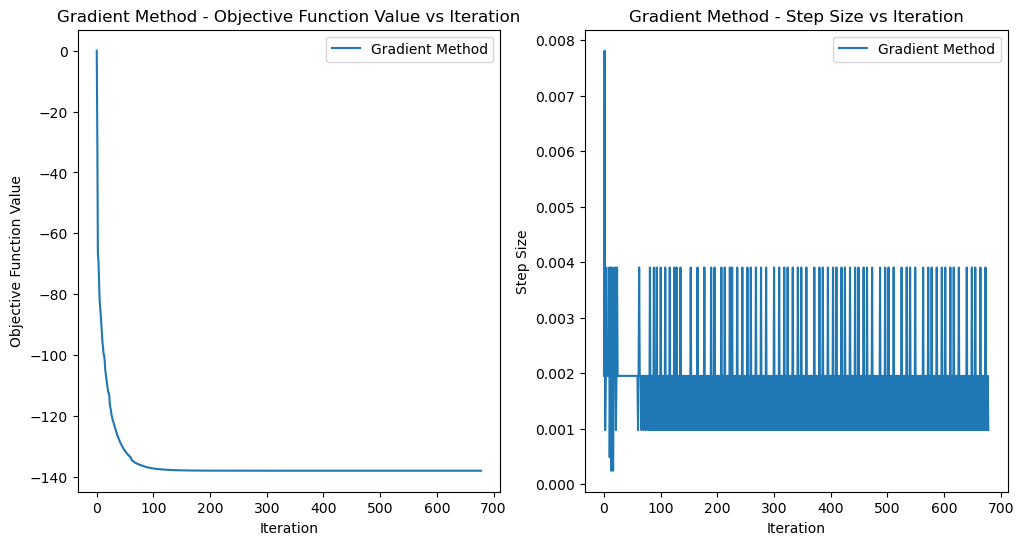

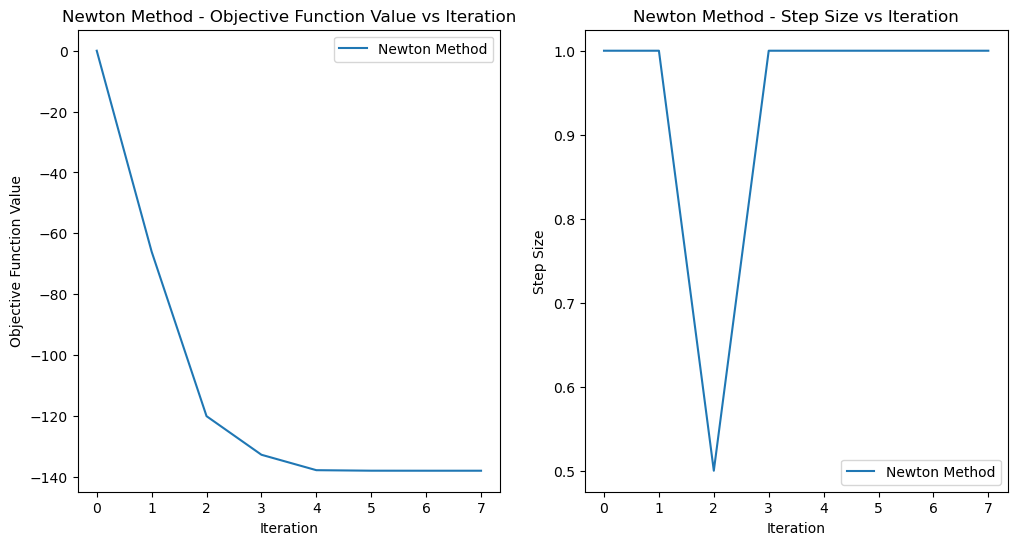

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def gradient_method(m, n, A, alpha=0.01, beta=0.5, max_iters=1000, grad_tol=1e-3):
    x = np.zeros(n)
    obj_values = []
    step_sizes = []

    for iter in range(max_iters):
        grad = A.T.dot(1 / (1 - A.dot(x))) - 1 / (1 + x) + 1 / (1 - x)
        val = -np.sum(np.log(1 - A.dot(x))) - np.sum(np.log(1 + x)) - np.sum(np.log(1 - x))
        obj_values.append(val)

        if np.linalg.norm(grad) < grad_tol:
            break

        v = -grad
        fprime = grad.dot(v)
        t = 1

        while np.max(A.dot(x + t * v)) >= 1 or np.max(np.abs(x + t * v)) >= 1:
            t = beta * t
        while -np.sum(np.log(1 - A.dot(x + t * v))) - np.sum(np.log(1 - (x + t * v) ** 2)) > val + alpha * t * fprime:
            t = beta * t

        x = x + t * v
        step_sizes.append(t)

    # 确保 obj_values 和 step_sizes 长度一致
    min_length = min(len(obj_values), len(step_sizes))
    obj_values = obj_values[:min_length]
    step_sizes = step_sizes[:min_length]

    return obj_values, step_sizes


def newton_method(m, n, A, alpha=0.01, beta=0.5, max_iters=1000, nt_tol=1e-8):
    x = np.zeros(n)
    obj_values = []
    step_sizes = []

    for iter in range(max_iters):
        val = -np.sum(np.log(1 - A.dot(x))) - np.sum(np.log(1 + x)) - np.sum(np.log(1 - x))
        obj_values.append(val)
        d = 1 / (1 - A.dot(x))
        grad = A.T.dot(d) - 1 / (1 + x) + 1 / (1 - x)
        hess = A.T.dot(np.diag(d ** 2)).dot(A) + np.diag(1 / (1 + x) ** 2 + 1 / (1 - x) ** 2)
        v = -np.linalg.solve(hess, grad)
        fprime = grad.dot(v)

        if np.abs(fprime) < nt_tol:
            break

        t = 1
        while np.max(A.dot(x + t * v)) >= 1 or np.max(np.abs(x + t * v)) >= 1:
            t = beta * t
        while -np.sum(np.log(1 - A.dot(x + t * v))) - np.sum(np.log(1 - (x + t * v) ** 2)) > val + alpha * t * fprime:
            t = beta * t

        x = x + t * v
        step_sizes.append(t)

    # 确保 obj_values 和 step_sizes 长度一致
    min_length = min(len(obj_values), len(step_sizes))
    obj_values = obj_values[:min_length]
    step_sizes = step_sizes[:min_length]

    return obj_values, step_sizes


# 示例参数设置
m = 200
n = 100
A = np.random.randn(m, n)

# 梯度法
obj_values_grad, step_sizes_grad = gradient_method(m, n, A)
iterations_grad = range(len(obj_values_grad))

# 牛顿法
obj_values_newton, step_sizes_newton = newton_method(m, n, A)
iterations_newton = range(len(obj_values_newton))

# 绘制梯度法目标函数值变化
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(iterations_grad, obj_values_grad, label='Gradient Method')
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.title('Gradient Method - Objective Function Value vs Iteration')
plt.legend()

# 绘制梯度法步长变化
plt.subplot(1, 2, 2)
plt.plot(iterations_grad, step_sizes_grad, label='Gradient Method')
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.title('Gradient Method - Step Size vs Iteration')
plt.legend()

plt.show()

# 绘制牛顿法目标函数值变化
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(iterations_newton, obj_values_newton, label='Newton Method')
plt.xlabel('Iteration')
plt.ylabel('Objective Function Value')
plt.title('Newton Method - Objective Function Value vs Iteration')
plt.legend()

# 绘制牛顿法步长变化
plt.subplot(1, 2, 2)
plt.plot(iterations_newton, step_sizes_newton, label='Newton Method')
plt.xlabel('Iteration')
plt.ylabel('Step Size')
plt.title('Newton Method - Step Size vs Iteration')
plt.legend()

plt.show()

# Question 6
Prove that the Newton Step and decrement for equality constrained problem are aﬀine invariant.

# Answer:
Consider the equality constrained convex optimization problem:
$$\begin{array}{ll}
\text{minimize} & f(x) \\
\text{subject to} & Ax = b,
\end{array}$$
where $f$ is convex and twice differentiable, $A \in \mathbb{R}^{m \times n}$, and $b \in \mathbb{R}^m$.
An affine transformation is defined as $x = T \tilde{x} + d$, where $T \in \mathbb{R}^{n \times n}$ is nonsingular, and $d \in \mathbb{R}^n$.
#### Affine Invariance:
A method or quantity is affine invariant if it does not change under an affine transformation of the variables.
#### Newton Step for Equality Constrained Problem:
The Newton step $\Delta x$ at a feasible point $x$ is obtained by solving the following KKT system:
$$\begin{bmatrix}
\nabla^2 f(x) & A^T \\
A & 0
\end{bmatrix}
\begin{bmatrix}
\Delta x \\
w
\end{bmatrix}
=
\begin{bmatrix}
-\nabla f(x) \\
0
\end{bmatrix},
$$where $w$ is the dual variable for the equality constraints.
The Newton decrement is defined as:
$$\lambda(x) = \left( \Delta x^T \nabla^2 f(x) \Delta x \right)^{1/2}.$$
#### Proof of Affine Invariance:
1. Transformed Problem:
Let $x = T \tilde{x} + d$. The transformed problem is:
$$\begin{array}{ll}
\text{minimize} & \tilde{f}(\tilde{x}) = f(T \tilde{x} + d) \\
\text{subject to} & A (T \tilde{x} + d) = b \quad \Rightarrow \quad \tilde{A} \tilde{x} = \tilde{b},
\end{array}

$$where $\tilde{A} = A T$ and $\tilde{b} = b - A d$.

2. Gradient and Hessian of Transformed Problem:
    - Gradient: $\nabla \tilde{f}(\tilde{x}) = T^T \nabla f(x)$.
    - Hessian: $\nabla^2 \tilde{f}(\tilde{x}) = T^T \nabla^2 f(x) T$.
3. Newton Step for Transformed Problem:

    The KKT system for the transformed problem is:
    $$\begin{bmatrix}
    \nabla^2 \tilde{f}(\tilde{x}) & \tilde{A}^T \\
    \tilde{A} & 0
    \end{bmatrix}
    \begin{bmatrix}
    \Delta \tilde{x} \\
    \tilde{w}
    \end{bmatrix}
    =
    \begin{bmatrix}
    -\nabla \tilde{f}(\tilde{x}) \\
    0
    \end{bmatrix}.$$

    Substituting the expressions for $\nabla \tilde{f}$, $\nabla^2 \tilde{f}$, $\tilde{A}$, and $\tilde{b}$, we get:

    $$\begin{bmatrix}
    T^T \nabla^2 f(x) T & T^T A^T \\
    A T & 0
    \end{bmatrix}
    \begin{bmatrix}
    \Delta \tilde{x} \\
    \tilde{w}
    \end{bmatrix}
    =
    \begin{bmatrix}
    -T^T \nabla f(x) \\
    0
    \end{bmatrix}.$$

    Multiply the first block row by $T^{-T}$ (the inverse of $T^T$):

    $$\begin{bmatrix}
    \nabla^2 f(x) T & A^T \\
    A T & 0
    \end{bmatrix}
    \begin{bmatrix}
    \Delta \tilde{x} \\
    \tilde{w}
    \end{bmatrix}
    =
    \begin{bmatrix}
    -\nabla f(x) \\
    0
    \end{bmatrix}.$$

    Let $\Delta x = T \Delta \tilde{x}$. Then the system becomes:

    $$\begin{bmatrix}
    \nabla^2 f(x) & A^T \\
    A & 0
    \end{bmatrix}
    \begin{bmatrix}
    \Delta x \\
    \tilde{w}
    \end{bmatrix}
    =
    \begin{bmatrix}
    -\nabla f(x) \\
    0
    \end{bmatrix},$$

    which is identical to the original KKT system. Thus, the Newton step transforms as $\Delta x = T \Delta \tilde{x}$, which is consistent with the affine transformation $x = T \tilde{x} + d$.

4. Newton Decrement for Transformed Problem:
    The Newton decrement for the transformed problem is:
    $$\tilde{\lambda}(\tilde{x}) = \left( \Delta \tilde{x}^T \nabla^2 \tilde{f}(\tilde{x}) \Delta \tilde{x} \right)^{1/2} = \left( \Delta \tilde{x}^T T^T \nabla^2 f(x) T \Delta \tilde{x} \right)^{1/2}.$$

    Substituting $\Delta \tilde{x} = T^{-1} \Delta x$, we get:
    $$\tilde{\lambda}(\tilde{x}) = \left( (T^{-1} \Delta x)^T T^T \nabla^2 f(x) T (T^{-1} \Delta x) \right)^{1/2} = \left( \Delta x^T \nabla^2 f(x) \Delta x \right)^{1/2} = \lambda(x).$$

    Thus, the Newton decrement is unchanged under the affine transformation.

# Question 7
Implement the infeasible start Newton method for solving the centering problem arising in the standar form LP,  

$$
\begin{array}{l l}{{\mathrm{minimize}}}&{{c^{\top}x-\displaystyle\sum_{i=1}^{n}\log x_{i}}}\\ {{\mathrm{subject~to}}}&{{A x=b,}}\end{array}
$$  

with variable $x$ . The data are $A\in\mathbf{R}^{m\times n}$ , with $m<n,c\in\mathbf{R}^{n}$ , and $b\in\mathbf{R}^{m}$ . You can assume that $A$ is ull rank. This problem cannot be solved when it is infeasible or unbounded below.  

Your code should accept $A,b,c$ , and $x_{0}$ , and return $x^{\star}$ , the primal optimal point, $\upsilon^{\star}$ , a dual optimal point, and the number of Newton steps executed. The initial point $x^{(0)}$ must satisfy $x^{(0)}\succ0$ , but it need not satisfy the equality constraints.  

Use the block elimination method to compute the Newton step. (You can also compute the Newton step via the KKT system, and compare the result to the Newton step computed via block elimination. The two steps should be close, but if any $x_{i}$ is very small, you might get a warning about the condition number of the KKT matrix.)  

Plot $||r(x,v)||_{2}$ , the norm of the concatenated primal and dual residuals, versus iteration $k$ for various problem data and initial points, to verify that your implementation achieves quadratic convergence. As stopping criterion, you can use $||r(x,v)||_{2}\leq10^{-6}$ (which means the problem was solved) or some maximum number of iterations (say, 50) was reached, which means it was not solved (likely because the problem is either infeasible or unbounded below).  

For a fixed problem instance, experiment with varying the algorithm parameters $\alpha$ and $\beta$ , observing the effect on the total number of Newton steps required.  

To generate problem data $(i.e.,\ A,b,c,x_{0})$ that are feasible, you can first generate $A$ , then random positive vector $p$ , and set $b=A p$ . You can be sure that the problem is not unbounded by making one row of $A$ have positive entries. You may also want to check that $A$ is full rank.  

Test the behavior of your implementation on data instances that are not feasible, and also ones that are unbounded below.  


1.  Form a centering problem that adds logarithmic barrier terms to enforce x > 0
2. Compute Newton steps by block elimination:
    - Calculate Hessian (H) and gradient (g)
    - Solve reduced system for dual variables (w)
    - Compute primal step direction (dx)
3. Use two-phase backtracking line search:
    - First ensure we stay in feasible region (x > 0)
    - Then ensure sufficient objective decrease
4. Track convergence via Newton decrement (λ²/2)

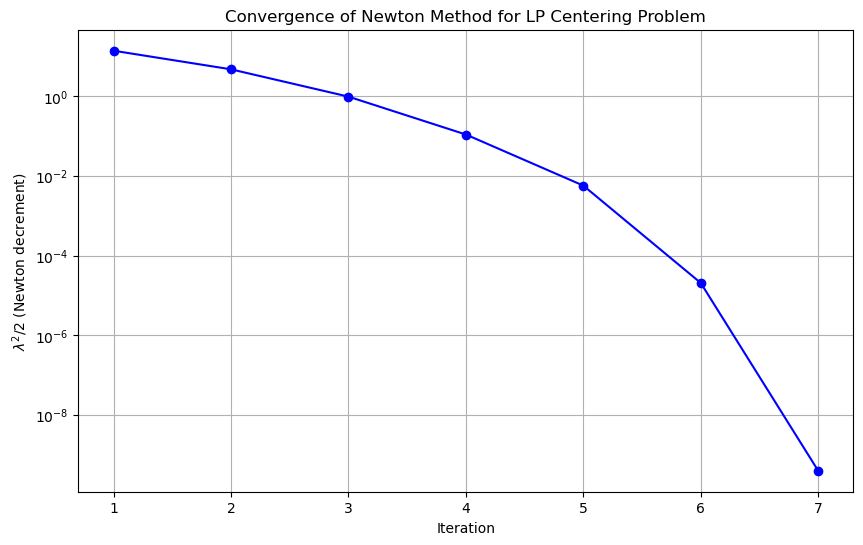

Primal feasibility: ||Ax - b|| = 7.427898172986502e-14
Dual feasibility: ||A^T*nu + c - 1/x|| = 8.084039672033172e-05
Number of iterations: 7


In [4]:
def lp_acent(A, b, c, x_0):
    """Solves standard form LP centering problem using Newton's method"""
    # Algorithm parameters
    ALPHA = 0.01
    BETA = 0.5
    EPSILON = 1e-6
    MAXITERS = 100
    
    # Check if x_0 is feasible
    if np.min(x_0) <= 0 or np.linalg.norm(A @ x_0 - b) > 1e-3:
        print('FAILED: Initial point not feasible')
        return None, None, None
    
    x = x_0.copy()
    lambda_hist = []
    
    for iter in range(MAXITERS):
        # Compute Hessian and gradient
        H = np.diag(x**(-2))
        g = c - x**(-1)
        
        # Newton step by block elimination method
        x_squared = np.diag(x**2)
        w = np.linalg.solve(A @ x_squared @ A.T, -A @ x_squared @ g)
        dx = -x_squared @ (A.T @ w + g)
        
        # Newton decrement squared
        lambdasqr = -g.T @ dx
        lambda_hist.append(lambdasqr/2)
        
        # Check convergence
        if lambdasqr/2 <= EPSILON:
            break
        
        # Backtracking line search - first ensure x remains positive
        t = 1.0
        while np.min(x + t*dx) <= 0:
            t = BETA * t
        
        # Then backtrack to satisfy sufficient decrease condition
        while (c.T @ (t*dx) - np.sum(np.log(x + t*dx)) + np.sum(np.log(x)) - ALPHA*t*g.T@dx > 0):
            t = BETA * t
        
        # Update x
        x = x + t*dx
    
    if iter == MAXITERS-1:
        print('ERROR: MAXITERS reached')
        return None, None, None
    
    return x, w, np.array(lambda_hist)

# Set random seed for reproducibility
np.random.seed(42)

# Generate random problem data (with smaller dimensions for testing)
m = 20  # number of constraints
n = 50  # number of variables

# Generate random A matrix and ensure it has full rank
A = np.random.randn(m, n)
while np.linalg.matrix_rank(A) < m:
    A = np.random.randn(m, n)

# Add a row with all positive elements to ensure bounded sublevel sets
A = np.vstack([A, np.abs(np.random.rand(1, n)) + 0.1])
m += 1  # update m after adding the row

# Generate random positive starting point
x_0 = np.abs(np.random.rand(n)) + 0.1

# Set b = A*x_0 to ensure feasibility
b = A @ x_0

# Random cost vector
c = np.random.randn(n)

# Run the barrier method
x_star, nu_star, lambda_hist = lp_acent(A, b, c, x_0)

# Plot the Newton decrement vs iteration
plt.figure(figsize=(10, 6))
plt.semilogy(range(1, len(lambda_hist) + 1), lambda_hist, 'bo-')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('$\\lambda^2/2$ (Newton decrement)')
plt.title('Convergence of Newton Method for LP Centering Problem')
plt.show()

# Verify KKT conditions
if x_star is not None:
    residual = A @ x_star - b
    dual_residual = A.T @ nu_star + c - 1/x_star
    print(f"Primal feasibility: ||Ax - b|| = {np.linalg.norm(residual)}")
    print(f"Dual feasibility: ||A^T*nu + c - 1/x|| = {np.linalg.norm(dual_residual)}")
    print(f"Number of iterations: {len(lambda_hist)}")